# nnU-Net: Nodule Segmentation on RexGrounding-CT

This notebook covers:
1. Environment setup and variable configuration
2. Dataset conversion from RexGrounding-CT format → nnU-Net format
3. Dataset fingerprinting and preprocessing
4. Model training (all folds)
5. Finding the best configuration
6. Inference and postprocessing

---
**Dataset specifics handled here:**
- Multi-finding masks (FxHxWxD) — only GGO channels extracted
- Instance-coded mask values → binary semantic mask (0/1)
- Variable depth (D: 104–1005 slices)
- HU-valued CT volumes
- JSON-driven train/valid/test splits

## 0. Install dependencies

In [6]:
# Install PyTorch first (edit the index-url to match your CUDA version)
# Check https://pytorch.org/get-started/locally/ for the right command
# Example for CUDA 12.1:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Then install nnU-Net
!pip install nnunetv2

# Optional: network topology visualisation
# !pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Configuration — edit these paths before running anything else

In [2]:
import os
from pathlib import Path
import shutil
import numpy as np
import nibabel as nib
from tqdm.auto import tqdm
import json

# Path to the JSON split file produced for Nodules
SPLIT_JSON = r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# Root directories where raw data already lives
CT_ROOT    = r"/home/chest_ct/code/data/data_volumes/train_fixed" # parent of train_XXX folders
SEG_ROOT   = r"/home/chest_ct/code/data/segmentations"            # flat folder of *_seg.nii.gz

# nnU-Net storage locations
NNUNET_RAW          = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_raw"
NNUNET_PREPROCESSED = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed"
NNUNET_RESULTS      = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_results"

# Dataset identity
DATASET_ID   = 104          # any unused 3-digit integer
DATASET_NAME = "Nodules"        # short, no spaces
DATASET_FULL_NAME = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
DATASET_RAW_DIR   = os.path.join(NNUNET_RAW, DATASET_FULL_NAME)

images_tr = Path(DATASET_RAW_DIR) / "imagesTr"
labels_tr = Path(DATASET_RAW_DIR) / "labelsTr"
images_ts = Path(DATASET_RAW_DIR) / "imagesTs"
labels_ts = Path(DATASET_RAW_DIR) / "labelsTs"


for d in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS]:
    os.makedirs(d, exist_ok=True)

# Set environment variables for the current process and all child processes
os.environ["nnUNet_raw"]          = NNUNET_RAW
os.environ["nnUNet_preprocessed"] = NNUNET_PREPROCESSED
os.environ["nnUNet_results"]      = NNUNET_RESULTS

print("Dataset folder:", DATASET_RAW_DIR)
print("Environment variables set.")

Dataset folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules
Environment variables set.


## 2. Convert RexGrounding-CT → nnU-Net format

In [3]:
# ── Convert training + validation (both go into imagesTr / labelsTr) ──
# nnU-Net manages its own CV splits, so train+valid are merged here.
# Test images go into imagesTs (no labels required).

import json

images_tr = Path(DATASET_RAW_DIR) / "imagesTr"
labels_tr = Path(DATASET_RAW_DIR) / "labelsTr"
images_ts = Path(DATASET_RAW_DIR) / "imagesTs"
labels_ts = Path(DATASET_RAW_DIR) / "labelsTs"

split_data = json.load(open(SPLIT_JSON, "r"))
train_cases = split_data.get("train", [])
test_cases = split_data.get("test", [])

print(f"  Training cases : {len(train_cases)}")
print(f"  Test images    : {len(test_cases)}")

  Training cases : 424
  Test images    : 100


In [4]:
# ── Write dataset.json ─────────────────────────────────────────────
# nnU-Net v2 requires this file in the dataset root.

from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json

generate_dataset_json(
    output_folder   = DATASET_RAW_DIR,
    channel_names   = {0: "CT"},     # single CT modality; nnU-Net will use CT-specific normalisation
    labels          = {"background": 0, "GGO": 1},
    num_training_cases = len(train_cases),
    file_ending     = ".nii.gz",
    dataset_name    = DATASET_FULL_NAME,
    reference       = "RexGrounding-CT",
    description     = "Binary GGO segmentation extracted from multi-finding RexGrounding-CT masks",
)

print("dataset.json written to:", DATASET_RAW_DIR)

dataset.json written to: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules


In [4]:
from pathlib import Path
import nibabel as nib
import numpy as np
from tqdm import tqdm

# folders
label_folders = [labels_tr, labels_ts]

def convert_multifinding_label_to_binary(label_path: Path, overwrite: bool = True):
    """
    Convert a label mask from:
        F x H x W x D
    to:
        H x W x D

    All finding channels are OR-combined into one binary mask.
    """

    img = nib.load(str(label_path))
    arr = img.get_fdata()

    original_shape = arr.shape
    original_unique = np.unique(arr)

    # Case 1: multi-finding label, expected F x H x W x D
    if arr.ndim == 4:
        # OR all finding channels
        binary_arr = np.any(arr > 0, axis=0).astype(np.uint8)

    # Case 2: already 3D
    elif arr.ndim == 3:
        binary_arr = (arr > 0).astype(np.uint8)

    else:
        raise ValueError(f"Unexpected label shape {arr.shape} in {label_path}")

    # Keep original affine and header
    new_img = nib.Nifti1Image(binary_arr, affine=img.affine, header=img.header)

    # Important: force uint8 label type
    new_img.set_data_dtype(np.uint8)

    if overwrite:
        save_path = label_path
    else:
        save_path = label_path.with_name(label_path.stem.replace(".nii", "") + "_binary.nii.gz")

    nib.save(new_img, str(save_path))

    return {
        "file": label_path.name,
        "original_shape": original_shape,
        "new_shape": binary_arr.shape,
        "original_unique": original_unique,
        "new_unique": np.unique(binary_arr),
        "voxel_fraction": binary_arr.mean(),
        "saved_to": save_path,
    }


# ---------------------------------------------------------
# Convert all labels in labelsTr and labelsTs
# ---------------------------------------------------------
results = []

for folder in label_folders:
    folder = Path(folder)

    label_files = sorted(folder.glob("*.nii.gz"))

    print(f"\nProcessing {folder}")
    print(f"Found {len(label_files)} label files")

    for label_path in tqdm(label_files):
        info = convert_multifinding_label_to_binary(
            label_path,
            overwrite=True,   # change to False first if you want test outputs
        )
        results.append(info)

print("\nDone converting labels.")

# Show first few results
for r in results[:5]:
    print(
        f"{r['file']} | "
        f"{r['original_shape']} -> {r['new_shape']} | "
        f"unique {r['new_unique']} | "
        f"fraction {r['voxel_fraction']:.4%}"
    )


Processing /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTr
Found 424 label files


100%|██████████| 424/424 [24:42<00:00,  3.50s/it]



Processing /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTs
Found 100 label files


100%|██████████| 100/100 [05:40<00:00,  3.40s/it]


Done converting labels.
train_10000_a_1.nii.gz | (1, 512, 512, 290) -> (512, 512, 290) | unique [0 1] | fraction 0.0004%
train_10017_a_2.nii.gz | (1, 512, 512, 450) -> (512, 512, 450) | unique [0 1] | fraction 0.0001%
train_10083_a_2.nii.gz | (5, 512, 512, 426) -> (512, 512, 426) | unique [0 1] | fraction 0.0010%
train_10083_b_2.nii.gz | (5, 512, 512, 462) -> (512, 512, 462) | unique [0 1] | fraction 0.0012%
train_10083_c_2.nii.gz | (7, 512, 512, 498) -> (512, 512, 498) | unique [0 1] | fraction 0.0016%


In [17]:
from pathlib import Path
import nibabel as nib
import numpy as np

ct_path = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1696_a_2.nii.gz")
mask_path = Path("/home/chest_ct/code/data/segmentations/segmentations/train_1696_a_2.nii.gz")

def print_nifti_metadata(path, name):
    img = nib.load(str(path))
    arr_shape = img.shape
    hdr = img.header

    print(f"\n{name}: {path.name}")
    print("-" * 60)
    print("Shape      :", arr_shape)
    print("Data dtype :", hdr.get_data_dtype())
    print("Zooms      :", hdr.get_zooms())
    print("Affine     :")
    print(img.affine)
    print("qform code :", hdr["qform_code"])
    print("sform code :", hdr["sform_code"])
    print("qform affine:")
    print(img.get_qform())
    print("sform affine:")
    print(img.get_sform())

print_nifti_metadata(ct_path, "CT")
print_nifti_metadata(mask_path, "MASK")


CT: train_1696_a_2.nii.gz
------------------------------------------------------------
Shape      : (512, 512, 466)
Data dtype : int16
Zooms      : (np.float32(0.71875), np.float32(0.71875), np.float32(0.75))
Affine     :
[[ -0.71875      0.           0.         221.        ]
 [  0.          -0.71875      0.          27.        ]
 [  0.           0.           0.75        17.94995117]
 [  0.           0.           0.           1.        ]]
qform code : 1
sform code : 1
qform affine:
[[ -0.71875      0.           0.         221.        ]
 [  0.          -0.71875      0.          27.        ]
 [  0.           0.           0.75        17.94995117]
 [  0.           0.           0.           1.        ]]
sform affine:
[[ -0.71875      0.           0.         221.        ]
 [  0.          -0.71875      0.          27.        ]
 [  0.           0.           0.75        17.94995117]
 [  0.           0.           0.           1.        ]]

MASK: train_1696_a_2.nii.gz
---------------------------

In [18]:
from pathlib import Path
import nibabel as nib
from tqdm import tqdm

# Existing paths:
# images_tr = Path(DATASET_RAW_DIR) / "imagesTr"
# labels_tr = Path(DATASET_RAW_DIR) / "labelsTr"
# images_ts = Path(DATASET_RAW_DIR) / "imagesTs"
# labels_ts = Path(DATASET_RAW_DIR) / "labelsTs"

def replace_label_headers_only(label_folder: Path, image_folder: Path, overwrite: bool = True):
    label_folder = Path(label_folder)
    image_folder = Path(image_folder)

    label_files = sorted(label_folder.glob("*.nii.gz"))

    print(f"\nProcessing labels: {label_folder}")
    print(f"Using images from : {image_folder}")
    print(f"Found labels      : {len(label_files)}")

    fixed = 0
    skipped = 0

    for label_path in tqdm(label_files):
        case_id = label_path.name.replace(".nii.gz", "")
        image_path = image_folder / f"{case_id}_0000.nii.gz"

        if not image_path.exists():
            print(f"\nMissing image for: {label_path.name}")
            print(f"Expected image  : {image_path}")
            skipped += 1
            continue

        ct_img = nib.load(str(image_path))
        label_img = nib.load(str(label_path))

        label_data = label_img.get_fdata().astype("uint8")

        if label_data.shape != ct_img.shape:
            print(f"\nShape mismatch: {case_id}")
            print(f"  CT shape    : {ct_img.shape}")
            print(f"  label shape : {label_data.shape}")
            print("  Skipping.")
            skipped += 1
            continue

        new_header = ct_img.header.copy()
        new_header.set_data_dtype("uint8")

        fixed_label = nib.Nifti1Image(
            label_data,
            affine=ct_img.affine,
            header=new_header
        )

        fixed_label.set_qform(ct_img.get_qform(), code=1)
        fixed_label.set_sform(ct_img.get_sform(), code=1)
        fixed_label.set_data_dtype("uint8")

        save_path = label_path if overwrite else label_path.with_name(case_id + "_fixed.nii.gz")
        nib.save(fixed_label, str(save_path))

        fixed += 1

    print(f"\nFinished: {label_folder}")
    print(f"Fixed   : {fixed}")
    print(f"Skipped : {skipped}")


replace_label_headers_only(labels_tr, images_tr, overwrite=True)
replace_label_headers_only(labels_ts, images_ts, overwrite=True)


Processing labels: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTr
Using images from : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/imagesTr
Found labels      : 424


100%|██████████| 424/424 [01:56<00:00,  3.65it/s]



Finished: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTr
Fixed   : 424
Skipped : 0

Processing labels: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTs
Using images from : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/imagesTs
Found labels      : 100


100%|██████████| 100/100 [00:27<00:00,  3.70it/s]


Finished: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/labelsTs
Fixed   : 100
Skipped : 0


## 3. Plan and preprocess

This extracts the dataset fingerprint, automatically selects patch sizes / batch sizes / normalisation, and writes preprocessed data to `nnUNet_preprocessed`.

> **Runtime:** expect 10–60 min depending on the number of cases and disk speed.

In [5]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity

Fingerprint extraction...
Dataset104_Nodules
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Attempting to find 3d_lowres config. 
Current spacing: [1.03       0.70410156 0.70410156]. 
Current patch size: (np.int64(96), np.int64(160), np.int64(160)). 
Current median shape: [330.09708738 500.48543689 500.48543689]
Attempting to find 3d_lowres config. 
Current spacing: [1.0609     0.72522461 0.72522461]. 
Current patch size: (np.int64(96), np.int64(160), np.int64(160)). 
Current median shape: [320.482609

In [7]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} -c "3d_fullres"

Fingerprint extraction...
Dataset104_Nodules
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Attempting to find 3d_lowres config. 
Current spacing: [1.03       0.70410156 0.70410156]. 
Current patch size: (np.int64(96), np.int64(160), np.int64(160)). 
Current median shape: [330.09708738 500.48543689 500.48543689]
Attempting to find 3d_lowres config. 
Current spacing: [1.0609     0.72522461 0.72522461]. 
Current patch size: (np.int64(96), np.int64(160), np.int64(160)). 
Current median shape: [320.48260911 485.90819116 485.90819116]
Attempting to find 3d_lowres config. 
Current spacing: [1.092727   0.74698135 0.74698135]. 
Current patch size: (np.int64(96), np.int64(160), np.int64(160)). 
Current median shape: [311.14816418 471.7555254

## 4. Train — 5-fold cross-validation

Each fold takes several hours on a modern GPU. Run folds in parallel across multiple GPUs by opening separate terminals (or Jupyter kernels) and setting `CUDA_VISIBLE_DEVICES` for each.

`--npz` saves validation softmax probabilities — **required** for `nnUNetv2_find_best_configuration`.

In [ ]:
CONFIGURATION = "3d_fullres"
CUDA_DEVICE = 0
fold = 0

!CUDA_VISIBLE_DEVICES={CUDA_DEVICE} nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} -tr customTrainer --npz


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-06-26 19:29:05.371543: Using torch.compile...
2026-06-26 19:29:05.750538: do_dummy_2d_data_aug: False
2026-06-26 19:29:05.751064: Using splits from existing split file: /home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed/Dataset104_Nodules/splits_final.json
2026-06-26 19:29:05.75

In [3]:
CONFIGURATION = "3d_fullres"
CUDA_DEVICE = 0
fold = 0
!CUDA_VISIBLE_DEVICES={CUDA_DEVICE} nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} -tr customTrainer --npz --c


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-06-27 15:24:33.080270: Using torch.compile...
2026-06-27 15:24:34.142082: do_dummy_2d_data_aug: False
2026-06-27 15:24:34.143029: Using splits from existing split file: /home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed/Dataset104_Nodules/splits_final.json
2026-06-27 15:24:34.14

In [ ]:
# ── Monitor training progress ──────────────────────────────────────
# Check the latest Dice and loss for each completed fold.

import json, pathlib, re

results_root = pathlib.Path(NNUNET_RESULTS)

for fold in range(N_FOLDS):
    summary_path = (
        results_root
        / DATASET_FULL_NAME
        / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
        / f"fold_{fold}"
        / "validation"
        / "summary.json"
    )
    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        # nnU-Net v2 stores per-class metrics under "metric_per_case" and "foreground_mean"
        fg = s.get("foreground_mean", {})
        dice = fg.get("Dice", fg.get("dice", "N/A"))
        print(f"Fold {fold} | Validation Dice (foreground mean): {dice}")
    else:
        print(f"Fold {fold} | summary.json not found (training not complete)")

## 5. Find the best configuration (optional but recommended)

In [8]:
# This compares all trained configurations and writes inference_instructions.txt
!nnUNetv2_find_best_configuration {DATASET_ID} --disable_ensembling -tr customTrainer

Traceback (most recent call last):
  File "/home/chest_ct/code/.venv/bin/nnUNetv2_find_best_configuration", line 10, in <module>
    sys.exit(find_best_configuration_entry_point())
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/.venv/lib/python3.12/site-packages/nnunetv2/evaluation/find_best_configuration.py", line 296, in find_best_configuration_entry_point
    find_best_configuration(dataset_name, model_dict, allow_ensembling=not args.disable_ensembling,
  File "/home/chest_ct/code/.venv/lib/python3.12/site-packages/nnunetv2/evaluation/find_best_configuration.py", line 92, in find_best_configuration
    allowed_trained_models = filter_available_models(deepcopy(allowed_trained_models), dataset_name_or_id)
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/chest_ct/code/.venv/lib/python3.12/site-packages/nnunetv2/evaluation/find_best_configuration.py", line 44, in filter_available_mode

In [ ]:
# Read the recommended inference command
import pathlib

instructions_path = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME / "inference_instructions.txt"
if instructions_path.exists():
    print(instructions_path.read_text())
else:
    print("inference_instructions.txt not found — did find_best_configuration complete?")

## 6. Inference

Input images must follow the same naming convention used during training:
`<case_id>_0000.nii.gz`

In [6]:
# ── Define inference I/O ───────────────────────────────────────────
INFER_INPUT_FOLDER  = str(images_ts)   # imagesTs prepared during conversion
INFER_OUTPUT_FOLDER = os.path.join(NNUNET_RESULTS, DATASET_FULL_NAME, "predictions")

os.makedirs(INFER_OUTPUT_FOLDER, exist_ok=True)
print("Input :", INFER_INPUT_FOLDER)
print("Output:", INFER_OUTPUT_FOLDER)

Input : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset104_Nodules/imagesTs
Output: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset104_Nodules/predictions


In [10]:
!nnUNetv2_predict \
    -i "{INFER_INPUT_FOLDER}" \
    -o "{INFER_OUTPUT_FOLDER}" \
    -d {DATASET_ID} \
    -c {CONFIGURATION} \
    -f 0 \
    -tr customTrainer \
    --save_probabilities


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 100 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 100 cases that I would like to predict

Predicting train_1015_a_1:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 216/216 [00:31<00:00,  6.92it/s]
sending off prediction to background worker for resampling and export
done with train_1015_a_1

Predicting train_1018_a_2:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 252/252 [00:37<00:00,  6.76it/s]
sending off prediction to background worker for 

In [15]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

gt_folder = labels_ts
pred_folder = Path(INFER_OUTPUT_FOLDER)

rows = []

def dice_score(gt, pred):
    gt = gt > 0
    pred = pred > 0

    inter = np.logical_and(gt, pred).sum()
    gt_sum = gt.sum()
    pred_sum = pred.sum()

    if gt_sum + pred_sum == 0:
        return 1.0

    return 2 * inter / (gt_sum + pred_sum)

for pred_path in sorted(pred_folder.glob("*.nii.gz")):
    case_id = pred_path.name.replace(".nii.gz", "")
    gt_path = gt_folder / f"{case_id}.nii.gz"

    if not gt_path.exists():
        print("Missing GT:", case_id)
        continue

    gt = nib.load(str(gt_path)).get_fdata() > 0
    pred = nib.load(str(pred_path)).get_fdata() > 0

    if gt.shape != pred.shape:
        print("Shape mismatch:", case_id, gt.shape, pred.shape)
        continue

    dice = dice_score(gt, pred)

    rows.append({
        "case_id": case_id,
        "dice": dice,
        "gt_voxels": int(gt.sum()),
        "pred_voxels": int(pred.sum()),
        "intersection_voxels": int(np.logical_and(gt, pred).sum())
    })

df = pd.DataFrame(rows)
df = df.sort_values("dice", ascending=False).reset_index(drop=True)

display(df.head(20))

,case_id,dice,gt_voxels,pred_voxels,intersection_voxels
0,train_1015_a_1,0.649916,285,312,194
1,train_1018_a_2,0.637854,264,407,214
2,valid_794_a_2,0.537287,3590,5448,2428
3,train_768_a_2,0.529598,1177,1036,586
4,valid_697_a_2,0.485793,679,412,265
5,train_739_a_2,0.468031,908,1438,549
6,train_13440_a_1,0.458937,254,160,95
7,train_907_a_1,0.440000,101,249,77
8,train_13148_a_2,0.409859,350,1070,291
9,train_13316_a_2,0.359384,4634,5628,1844


In [20]:
df.head(50)

,case_id,dice,gt_voxels,pred_voxels,intersection_voxels
0,train_1015_a_1,0.649916,285,312,194
1,train_1018_a_2,0.637854,264,407,214
2,valid_794_a_2,0.537287,3590,5448,2428
3,train_768_a_2,0.529598,1177,1036,586
4,valid_697_a_2,0.485793,679,412,265
5,train_739_a_2,0.468031,908,1438,549
6,train_13440_a_1,0.458937,254,160,95
7,train_907_a_1,0.440000,101,249,77
8,train_13148_a_2,0.409859,350,1070,291
9,train_13316_a_2,0.359384,4634,5628,1844


CT shape  : (512, 512, 316)
GT shape  : (512, 512, 316) voxels: 1501
Pred shape: (512, 512, 316) voxels: 1208
GT best slice        : 90 GT voxels on slice: 114
Prediction best slice: 136 Pred voxels on slice: 73


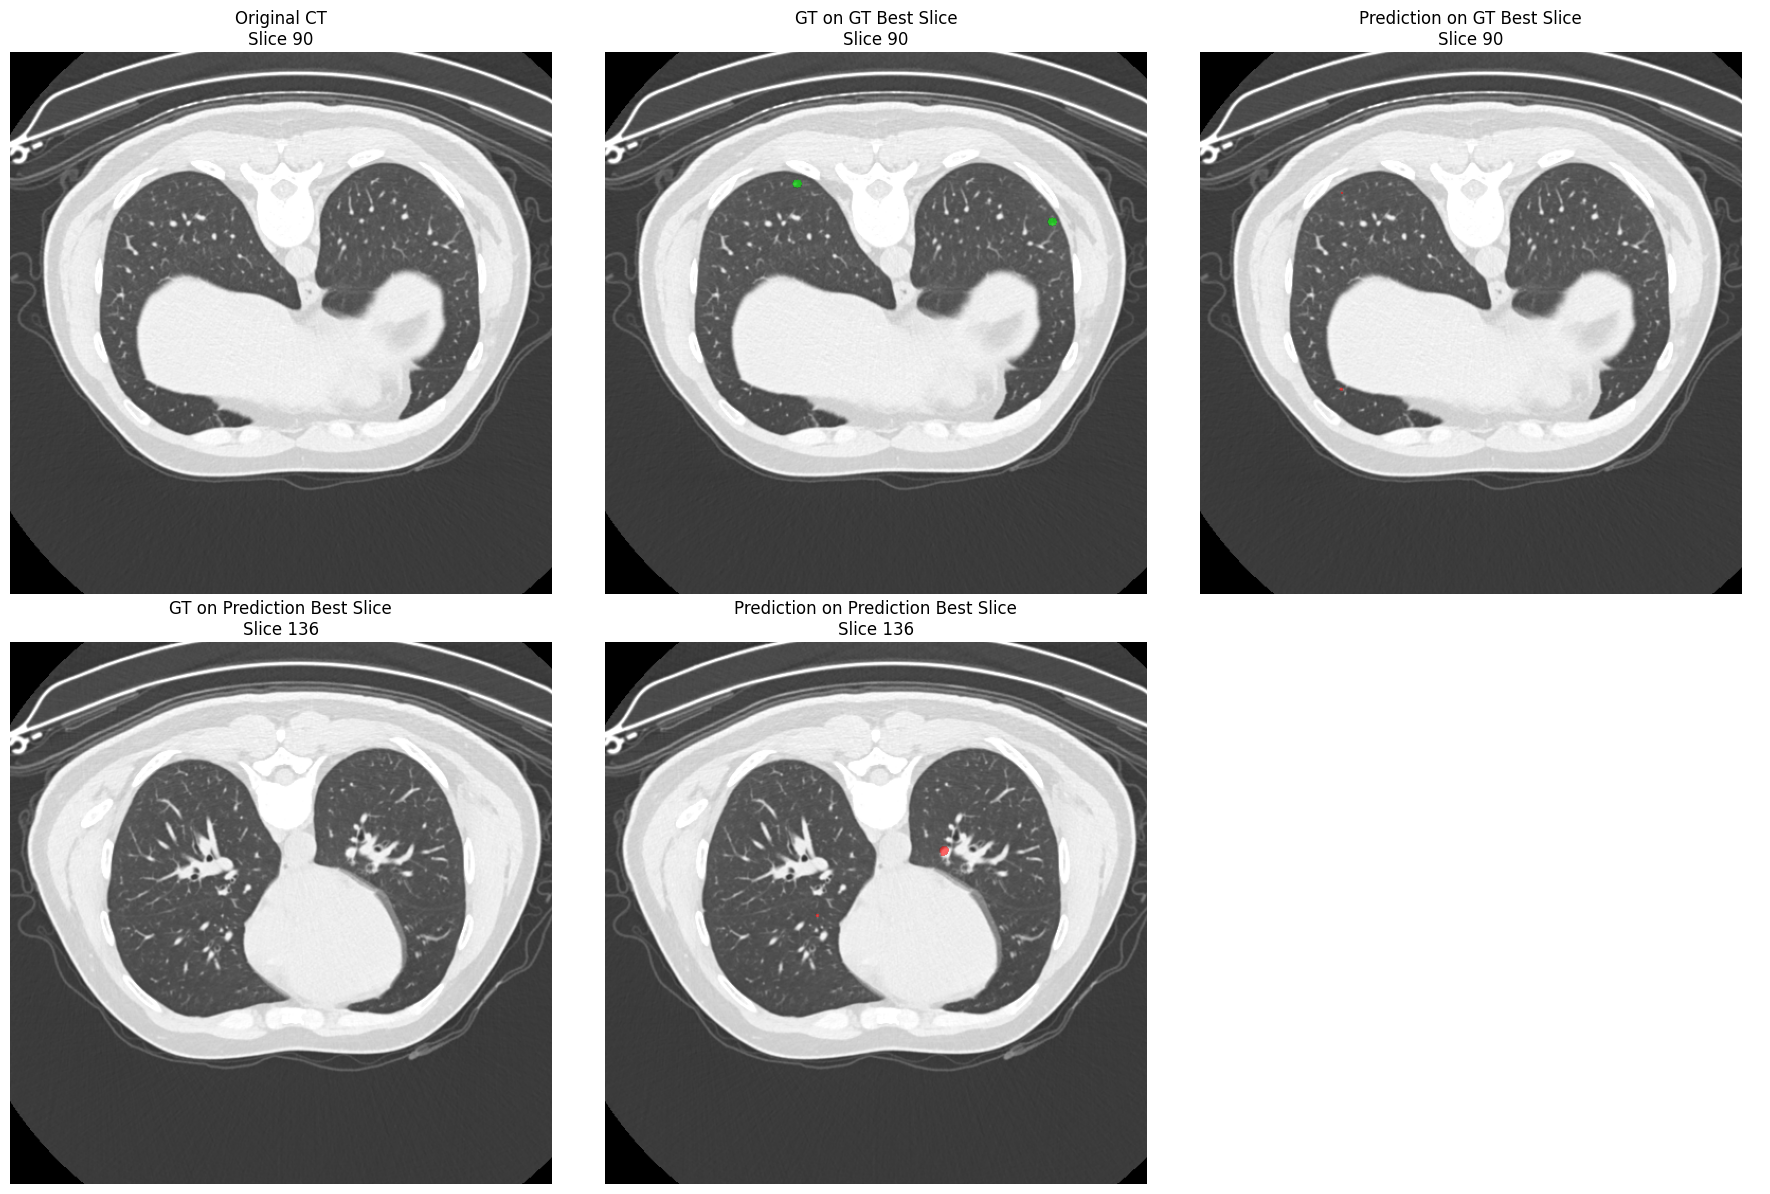

In [32]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap

# =========================
# Set paths
# =========================
case_id = "valid_1196_a_1"  # without .nii.gz

ct_path   = Path(INFER_INPUT_FOLDER) / f"{case_id}_0000.nii.gz"
gt_path   = labels_ts / f"{case_id}.nii.gz"
pred_path = Path(INFER_OUTPUT_FOLDER) / f"{case_id}.nii.gz"

# =========================
# Load data
# =========================
ct = nib.load(str(ct_path)).get_fdata()
gt = nib.load(str(gt_path)).get_fdata()
pred = nib.load(str(pred_path)).get_fdata()

gt = gt > 0
pred = pred > 0

print("CT shape  :", ct.shape)
print("GT shape  :", gt.shape, "voxels:", gt.sum())
print("Pred shape:", pred.shape, "voxels:", pred.sum())

# =========================
# Choose best slices separately
# =========================
gt_slice_scores = gt.sum(axis=(0, 1))
pred_slice_scores = pred.sum(axis=(0, 1))

if gt_slice_scores.max() > 0:
    z_gt = int(np.argmax(gt_slice_scores))
else:
    z_gt = ct.shape[2] // 2

if pred_slice_scores.max() > 0:
    z_pred = int(np.argmax(pred_slice_scores))
else:
    z_pred = ct.shape[2] // 2

print("GT best slice        :", z_gt, "GT voxels on slice:", int(gt_slice_scores[z_gt]))
print("Prediction best slice:", z_pred, "Pred voxels on slice:", int(pred_slice_scores[z_pred]))

# =========================
# CT windowing
# =========================
def window_ct(img, level=-600, width=1500):
    low = level - width / 2
    high = level + width / 2
    img = np.clip(img, low, high)
    return (img - low) / (high - low)

# =========================
# Helper function
# =========================
def get_display_slices(z):
    ct_slice = window_ct(ct[:, :, z])
    gt_slice = gt[:, :, z]
    pred_slice = pred[:, :, z]

    # optional orientation fix for display
    ct_slice = np.rot90(ct_slice)
    gt_slice = np.rot90(gt_slice)
    pred_slice = np.rot90(pred_slice)

    gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
    pred_overlay = np.ma.masked_where(pred_slice == 0, pred_slice)

    return ct_slice, gt_overlay, pred_overlay

# Slices from GT best slice
ct_gt_best, gt_on_gt_best, pred_on_gt_best = get_display_slices(z_gt)

# Slices from prediction best slice
ct_pred_best, gt_on_pred_best, pred_on_pred_best = get_display_slices(z_pred)

# =========================
# Plot 5 panels in 2 rows
# =========================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# 1. Original CT, use GT best slice as reference
axes[0].imshow(ct_gt_best, cmap="gray")
axes[0].set_title(f"Original CT\nSlice {z_gt}")

# 2. GT on GT best slice
axes[1].imshow(ct_gt_best, cmap="gray")
axes[1].imshow(gt_on_gt_best, cmap=ListedColormap(["lime"]), alpha=0.6)
axes[1].set_title(f"GT on GT Best Slice\nSlice {z_gt}")

# 3. Prediction on GT best slice
axes[2].imshow(ct_gt_best, cmap="gray")
axes[2].imshow(pred_on_gt_best, cmap=ListedColormap(["red"]), alpha=0.6)
axes[2].set_title(f"Prediction on GT Best Slice\nSlice {z_gt}")

# 4. GT on prediction best slice
axes[3].imshow(ct_pred_best, cmap="gray")
axes[3].imshow(gt_on_pred_best, cmap=ListedColormap(["lime"]), alpha=0.6)
axes[3].set_title(f"GT on Prediction Best Slice\nSlice {z_pred}")

# 5. Prediction on prediction best slice
axes[4].imshow(ct_pred_best, cmap="gray")
axes[4].imshow(pred_on_pred_best, cmap=ListedColormap(["red"]), alpha=0.6)
axes[4].set_title(f"Prediction on Prediction Best Slice\nSlice {z_pred}")

# 6th subplot is unused
axes[5].axis("off")

for ax in axes[:5]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── Apply postprocessing (if find_best_configuration was run) ──────
import glob, pathlib

trainer_folder = (
    pathlib.Path(NNUNET_RESULTS)
    / DATASET_FULL_NAME
    / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
)

pp_pkl = list(trainer_folder.glob("**/postprocessing.pkl"))
if pp_pkl:
    pp_pkl = pp_pkl[0]
    plans_json   = trainer_folder / "plans.json"
    dataset_json = pathlib.Path(DATASET_RAW_DIR) / "dataset.json"

    INFER_PP_OUTPUT = INFER_OUTPUT_FOLDER + "_pp"
    os.makedirs(INFER_PP_OUTPUT, exist_ok=True)

    !nnUNetv2_apply_postprocessing \
        -i  "{INFER_OUTPUT_FOLDER}" \
        -o  "{INFER_PP_OUTPUT}" \
        --pp_pkl_file "{pp_pkl}" \
        -plans_json "{plans_json}" \
        -dataset_json "{dataset_json}"
else:
    print("No postprocessing.pkl found — skipping. Run find_best_configuration first.")

## 7. Evaluate predictions (if ground-truth labels exist for test set)

In [ ]:
# ── Convert test masks to binary labels first ──────────────────────
# Skip this cell if your test split has no ground-truth labels.

TEST_LABELS_DIR = pathlib.Path(DATASET_RAW_DIR) / "labelsTs"
TEST_LABELS_DIR.mkdir(exist_ok=True)

for entry in tqdm(split_data.get("test", []), desc="Test labels"):
    case_id  = entry["name"].replace(".nii.gz", "")
    seg_path = entry["seg_path"]
    ggo_chs  = entry["ggo_channels"]
    lbl_dest = TEST_LABELS_DIR / f"{case_id}.nii.gz"

    if not lbl_dest.exists() and os.path.isfile(seg_path):
        binary, affine, header = extract_ggo_mask(seg_path, ggo_chs)
        lbl_img = nib.Nifti1Image(binary, affine, header)
        lbl_img.set_data_dtype(np.uint8)
        nib.save(lbl_img, str(lbl_dest))

print("Test labels written.")

In [ ]:
# ── Compute Dice / IoU on the test set ────────────────────────────
import numpy as np
import nibabel as nib
from pathlib import Path


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = (pred > 0).astype(np.uint8)
    gt   = (gt   > 0).astype(np.uint8)
    intersection = (pred & gt).sum()
    denom = pred.sum() + gt.sum()
    return (2.0 * intersection / denom) if denom > 0 else 1.0


def iou_score(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = (pred > 0).astype(np.uint8)
    gt   = (gt   > 0).astype(np.uint8)
    intersection = (pred & gt).sum()
    union = (pred | gt).sum()
    return (intersection / union) if union > 0 else 1.0


pred_dir  = Path(INFER_PP_OUTPUT if pp_pkl else INFER_OUTPUT_FOLDER)
label_dir = TEST_LABELS_DIR

dice_scores, iou_scores = [], []
missing = []

for lbl_path in sorted(label_dir.glob("*.nii.gz")):
    case_id   = lbl_path.stem.replace(".nii", "")
    pred_path = pred_dir / lbl_path.name

    if not pred_path.exists():
        missing.append(case_id)
        continue

    gt_arr   = nib.load(str(lbl_path)).get_fdata()
    pred_arr = nib.load(str(pred_path)).get_fdata()

    d = dice_score(pred_arr, gt_arr)
    i = iou_score(pred_arr, gt_arr)
    dice_scores.append(d)
    iou_scores.append(i)

print(f"Evaluated {len(dice_scores)} cases")
if missing:
    print(f"Missing predictions for: {missing}")
if dice_scores:
    print(f"\nDice  — mean: {np.mean(dice_scores):.4f}  std: {np.std(dice_scores):.4f}  "
          f"min: {np.min(dice_scores):.4f}  max: {np.max(dice_scores):.4f}")
    print(f"IoU   — mean: {np.mean(iou_scores):.4f}  std: {np.std(iou_scores):.4f}  "
          f"min: {np.min(iou_scores):.4f}  max: {np.max(iou_scores):.4f}")

## 8. Visualise a prediction

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from pathlib import Path


def show_case(
    ct_path: str,
    pred_path: str,
    gt_path: str | None = None,
    n_slices: int = 6,
    hu_window: tuple[float, float] = (-1000, 400),
):
    ct   = nib.load(ct_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata() if gt_path else None

    # Find slices that contain GGO foreground
    ggo_slices = np.where(pred.sum(axis=(0, 1)) > 0)[0]
    if len(ggo_slices) == 0:
        ggo_slices = np.linspace(0, ct.shape[2]-1, n_slices, dtype=int)
    else:
        idx = np.linspace(0, len(ggo_slices)-1, n_slices, dtype=int)
        ggo_slices = ggo_slices[idx]

    ncols = n_slices
    nrows = 3 if gt is not None else 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    fig.suptitle(Path(ct_path).name, fontsize=12)

    hu_min, hu_max = hu_window

    for col, sl in enumerate(ggo_slices):
        ct_sl   = np.clip(ct[:, :, sl], hu_min, hu_max)
        ct_norm = (ct_sl - hu_min) / (hu_max - hu_min)

        axes[0, col].imshow(ct_norm.T, cmap="gray", origin="lower")
        axes[0, col].set_title(f"CT  z={sl}", fontsize=8)
        axes[0, col].axis("off")

        axes[1, col].imshow(ct_norm.T, cmap="gray", origin="lower")
        axes[1, col].imshow(pred[:, :, sl].T, cmap="Reds", alpha=0.45, origin="lower", vmin=0, vmax=1)
        axes[1, col].set_title("Prediction", fontsize=8)
        axes[1, col].axis("off")

        if gt is not None:
            axes[2, col].imshow(ct_norm.T, cmap="gray", origin="lower")
            axes[2, col].imshow(gt[:, :, sl].T, cmap="Greens", alpha=0.45, origin="lower", vmin=0, vmax=1)
            axes[2, col].set_title("Ground truth", fontsize=8)
            axes[2, col].axis("off")

    plt.tight_layout()
    plt.show()


# ── Pick the first test case that has a prediction ─────────────────
pred_dir = Path(INFER_PP_OUTPUT if pp_pkl else INFER_OUTPUT_FOLDER)
preds    = sorted(pred_dir.glob("*.nii.gz"))

if preds:
    first_case = preds[0].stem.replace(".nii", "")
    ct_file    = images_ts / f"{first_case}_0000.nii.gz"
    gt_file    = TEST_LABELS_DIR / f"{first_case}.nii.gz"

    show_case(
        ct_path   = str(ct_file),
        pred_path = str(preds[0]),
        gt_path   = str(gt_file) if gt_file.exists() else None,
    )
else:
    print("No predictions found.")

## 9. Export and portability

In [ ]:
# Pack the trained model into a zip for transfer or sharing
MODEL_ZIP = os.path.join(NNUNET_RESULTS, f"{DATASET_FULL_NAME}_model.zip")

!nnUNetv2_export_model_to_zip \
    -d {DATASET_ID} \
    -o "{MODEL_ZIP}"

print("Model exported to:", MODEL_ZIP)

In [ ]:
# On the target machine, install with:
# !nnUNetv2_install_pretrained_model_from_zip "{MODEL_ZIP}"
print(f"To install on another machine:\n"
      f"  nnUNetv2_install_pretrained_model_from_zip {MODEL_ZIP}")

---
## Appendix: Common issues

| Issue | Fix |
|---|---|
| `nnUNet_raw not set` | Re-run cell 1 (sets `os.environ` for this kernel) |
| `dataset.json` errors | Re-run the `generate_dataset_json` cell |
| CUDA OOM during training | Reduce `nnUNet_n_proc_DA` or use `--c 3d_lowres` |
| NaN loss | Check CT values — extreme HU outliers can destabilise normalisation; clip to [-1024, 3071] before conversion |
| Very low Dice on GGO | GGO is subtle and diffuse; try ensembling 3d_fullres + 2d, and consider a lower `foreground_threshold` in postprocessing |
| Mask shape mismatch | Confirm the segmentation is `F×H×W×D` not transposed — adjust `extract_ggo_mask` indexing if needed |
| Variable voxel spacing | nnU-Net handles this automatically via anisotropic resampling; check spacing in the fingerprint |
